# Step 13A: Event-Type Diagnostic

Step 13 found a median event-day sales change of −7.066% for
intermittent demand and −5.732% for lumpy demand.

This diagnostic checks whether the negative event-day result is
concentrated in Cultural, National, Religious, Sporting or
multiple-event dates.

It also checks whether event dates coincide with full-store
zero-sales days. Full-store zero sales are treated only as a possible
closure proxy and not as confirmed evidence that a store was closed.

The analysis is descriptive and does not establish that an event
caused the observed change in sales.

In [17]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

np.random.seed(42)

project_root = Path("..")

subset_data_path = (
    project_root
    / "data"
    / "subset"
)

raw_data_path = (
    project_root
    / "data"
    / "raw"
)

tables_path = (
    project_root
    / "outputs"
    / "tables"
    / "step13A"
)

figures_path = (
    project_root
    / "outputs"
    / "figures"
    / "step13A"
)

tables_path.mkdir(
    parents=True,
    exist_ok=True
)

figures_path.mkdir(
    parents=True,
    exist_ok=True
)

subset_file = (
    subset_data_path
    / "selected_m5_data.parquet"
)

store_daily_file = (
    project_root
    / "outputs"
    / "tables"
    / "store_daily_sales.csv"
)

print("Subset file:", subset_file)
print("Store-daily file:", store_daily_file)

Subset file: ..\data\subset\selected_m5_data.parquet
Store-daily file: ..\outputs\tables\store_daily_sales.csv


In [18]:
event_data = pd.read_parquet(
    subset_file,
    columns=[
        "id",
        "demand_type",
        "store_id",
        "date",
        "sales",
        "event_name_1",
        "event_type_1",
        "event_name_2",
        "event_type_2"
    ]
)

event_data["date"] = pd.to_datetime(
    event_data["date"]
)

demand_type_order = [
    "smooth",
    "erratic",
    "intermittent",
    "lumpy"
]

event_data["demand_type"] = pd.Categorical(
    event_data["demand_type"],
    categories=demand_type_order,
    ordered=True
)

event_data = event_data.sort_values(
    ["id", "date"]
).reset_index(drop=True)

print("Rows:", len(event_data))
print("Series:", event_data["id"].nunique())
print(
    "Date range:",
    event_data["date"].min(),
    "to",
    event_data["date"].max()
)

print()
print(
    event_data[
        ["id", "demand_type"]
    ]
    .drop_duplicates()["demand_type"]
    .value_counts(sort=False)
)

Rows: 1552800
Series: 800
Date range: 2011-01-29 00:00:00 to 2016-05-22 00:00:00

demand_type
smooth          200
erratic         200
intermittent    200
lumpy           200
Name: count, dtype: int64


In [19]:
event_data["event_flag"] = (
    event_data["event_name_1"].notna()
    | event_data["event_name_2"].notna()
)

event_data["event_type_label"] = (
    event_data["event_type_1"]
    .fillna("No event")
    .astype("string")
)

event_data["event_name_label"] = (
    event_data["event_name_1"]
    .fillna("No event")
    .astype("string")
)

multiple_event_mask = (
    event_data["event_type_2"].notna()
)

event_data.loc[
    multiple_event_mask,
    "event_type_label"
] = "Multiple"

event_data.loc[
    multiple_event_mask,
    "event_name_label"
] = "Multiple events"

event_type_code_mapping = {
    "No event": 0,
    "Cultural": 1,
    "National": 2,
    "Religious": 3,
    "Sporting": 4,
    "Multiple": 5
}

event_data["event_type_encoded"] = (
    event_data["event_type_label"]
    .map(event_type_code_mapping)
    .astype("int8")
)

print(
    "Event rows:",
    int(event_data["event_flag"].sum())
)

print()
print(
    event_data[
        "event_type_label"
    ].value_counts()
)

Event rows: 126400

event_type_label
No event     1426400
Religious      41600
National       40800
Cultural       28800
Sporting       12000
Multiple        3200
Name: count, dtype: Int64


In [20]:
def positive_percentage(values):
    valid_values = values.dropna()
    
    if len(valid_values) == 0:
        return np.nan
    
    return (
        valid_values.gt(0).mean()
        * 100
    )

In [21]:
non_event_baseline = (
    event_data.loc[
        ~event_data["event_flag"]
    ]
    .groupby(
        ["id", "demand_type"],
        observed=True,
        as_index=False
    )
    .agg(
        mean_non_event_sales=(
            "sales",
            "mean"
        )
    )
)

print(
    "Series with a non-event baseline:",
    non_event_baseline["id"].nunique()
)

print(
    "Missing non-event baselines:",
    non_event_baseline[
        "mean_non_event_sales"
    ].isna().sum()
)

print(
    "Zero non-event baselines:",
    non_event_baseline[
        "mean_non_event_sales"
    ].eq(0).sum()
)

Series with a non-event baseline: 800
Missing non-event baselines: 0
Zero non-event baselines: 0


In [22]:
event_type_series_effect = (
    event_data.loc[
        event_data["event_flag"]
    ]
    .groupby(
        [
            "id",
            "demand_type",
            "event_type_encoded",
            "event_type_label"
        ],
        observed=True,
        as_index=False
    )
    .agg(
        mean_event_sales=(
            "sales",
            "mean"
        ),
        event_rows=(
            "date",
            "size"
        ),
        event_dates=(
            "date",
            "nunique"
        )
    )
    .merge(
        non_event_baseline,
        on=[
            "id",
            "demand_type"
        ],
        how="left",
        validate="many_to_one"
    )
)

event_type_series_effect[
    "event_uplift_pct"
] = np.where(
    event_type_series_effect[
        "mean_non_event_sales"
    ] > 0,
    (
        (
            event_type_series_effect[
                "mean_event_sales"
            ]
            / event_type_series_effect[
                "mean_non_event_sales"
            ]
        ) - 1
    ) * 100,
    np.nan
)

print(
    "Event-type series rows:",
    len(event_type_series_effect)
)

print(
    "Missing event uplift values:",
    event_type_series_effect[
        "event_uplift_pct"
    ].isna().sum()
)

Event-type series rows: 4000
Missing event uplift values: 0


In [24]:
event_type_summary = (
    event_type_series_effect
    .groupby(
        [
            "demand_type",
            "event_type_encoded",
            "event_type_label"
        ],
        observed=True,
        as_index=False
    )
    .agg(
        series_count=(
            "id",
            "nunique"
        ),
        event_dates=(
            "event_dates",
            "max"
        ),
        mean_event_uplift_pct=(
            "event_uplift_pct",
            "mean"
        ),
        median_event_uplift_pct=(
            "event_uplift_pct",
            "median"
        ),
        positive_series_pct=(
            "event_uplift_pct",
            positive_percentage
        )
    )
    .sort_values(
        [
            "demand_type",
            "event_type_encoded"
        ]
    )
    .reset_index(drop=True)
)

event_type_summary[
    [
        "mean_event_uplift_pct",
        "median_event_uplift_pct",
        "positive_series_pct"
    ]
] = event_type_summary[
    [
        "mean_event_uplift_pct",
        "median_event_uplift_pct",
        "positive_series_pct"
    ]
].round(3)

event_type_summary

,demand_type,event_type_encoded,event_type_label,series_count,event_dates,mean_event_uplift_pct,median_event_uplift_pct,positive_series_pct
0,smooth,1,Cultural,200,36,-1.970,-3.340,41.5
1,smooth,2,National,200,51,-12.054,-12.541,13.5
2,smooth,3,Religious,200,52,0.047,-0.422,48.5
3,smooth,4,Sporting,200,15,9.710,4.847,63.0
4,smooth,5,Multiple,200,4,8.680,2.188,53.5
5,erratic,1,Cultural,200,36,2.288,0.795,53.5
6,erratic,2,National,200,51,-14.585,-14.223,14.5
7,erratic,3,Religious,200,52,0.071,0.338,50.5
8,erratic,4,Sporting,200,15,7.836,4.441,57.5
9,erratic,5,Multiple,200,4,19.054,10.432,54.0


In [25]:
binary_series_effect = (
    event_data
    .groupby(
        [
            "id",
            "demand_type",
            "event_flag"
        ],
        observed=True
    )["sales"]
    .mean()
    .unstack("event_flag")
    .reindex(
        columns=[False, True]
    )
    .rename(
        columns={
            False: "mean_non_event_sales",
            True: "mean_event_sales"
        }
    )
    .reset_index()
)

binary_series_effect[
    "event_uplift_pct"
] = np.where(
    binary_series_effect[
        "mean_non_event_sales"
    ] > 0,
    (
        (
            binary_series_effect[
                "mean_event_sales"
            ]
            / binary_series_effect[
                "mean_non_event_sales"
            ]
        ) - 1
    ) * 100,
    np.nan
)

binary_event_summary = (
    binary_series_effect
    .groupby(
        "demand_type",
        observed=True
    )
    .agg(
        binary_median_uplift_pct=(
            "event_uplift_pct",
            "median"
        ),
        binary_mean_uplift_pct=(
            "event_uplift_pct",
            "mean"
        ),
        binary_positive_series_pct=(
            "event_uplift_pct",
            positive_percentage
        )
    )
    .reindex(demand_type_order)
    .round(3)
)

binary_event_summary

,binary_median_uplift_pct,binary_mean_uplift_pct,binary_positive_series_pct
demand_type,,,
smooth,-3.707,-3.183,31.5
erratic,-3.150,-2.937,32.5
intermittent,-7.066,-6.598,29.5
lumpy,-5.732,-4.257,36.5


In [26]:
lowest_type_rows = (
    event_type_summary.loc[
        event_type_summary
        .groupby(
            "demand_type",
            observed=True
        )["median_event_uplift_pct"]
        .idxmin()
    ]
    [
        [
            "demand_type",
            "event_type_label",
            "median_event_uplift_pct"
        ]
    ]
    .rename(
        columns={
            "event_type_label":
                "strongest_negative_event_type",
            "median_event_uplift_pct":
                "strongest_negative_median_pct"
        }
    )
)

highest_type_rows = (
    event_type_summary.loc[
        event_type_summary
        .groupby(
            "demand_type",
            observed=True
        )["median_event_uplift_pct"]
        .idxmax()
    ]
    [
        [
            "demand_type",
            "event_type_label",
            "median_event_uplift_pct"
        ]
    ]
    .rename(
        columns={
            "event_type_label":
                "highest_event_type",
            "median_event_uplift_pct":
                "highest_median_pct"
        }
    )
)

binary_vs_typed_event = (
    binary_event_summary
    .reset_index()
    .merge(
        lowest_type_rows,
        on="demand_type",
        how="left",
        validate="one_to_one"
    )
    .merge(
        highest_type_rows,
        on="demand_type",
        how="left",
        validate="one_to_one"
    )
)

binary_vs_typed_event

,demand_type,binary_median_uplift_pct,binary_mean_uplift_pct,binary_positive_series_pct,strongest_negative_event_type,strongest_negative_median_pct,highest_event_type,highest_median_pct
0,smooth,-3.707,-3.183,31.5,National,-12.541,Sporting,4.847
1,erratic,-3.150,-2.937,32.5,National,-14.223,Multiple,10.432
2,intermittent,-7.066,-6.598,29.5,Multiple,-49.373,Religious,0.125
3,lumpy,-5.732,-4.257,36.5,Multiple,-24.469,Cultural,-1.591


In [27]:
event_name_series_effect = (
    event_data.loc[
        event_data["event_flag"]
    ]
    .groupby(
        [
            "id",
            "demand_type",
            "event_name_label",
            "event_type_label"
        ],
        observed=True,
        as_index=False
    )
    .agg(
        mean_event_sales=(
            "sales",
            "mean"
        ),
        event_dates=(
            "date",
            "nunique"
        )
    )
    .merge(
        non_event_baseline,
        on=[
            "id",
            "demand_type"
        ],
        how="left",
        validate="many_to_one"
    )
)

event_name_series_effect[
    "event_uplift_pct"
] = np.where(
    event_name_series_effect[
        "mean_non_event_sales"
    ] > 0,
    (
        (
            event_name_series_effect[
                "mean_event_sales"
            ]
            / event_name_series_effect[
                "mean_non_event_sales"
            ]
        ) - 1
    ) * 100,
    np.nan
)

event_name_summary = (
    event_name_series_effect
    .groupby(
        [
            "demand_type",
            "event_type_label",
            "event_name_label"
        ],
        observed=True,
        as_index=False
    )
    .agg(
        series_count=(
            "id",
            "nunique"
        ),
        event_dates=(
            "event_dates",
            "max"
        ),
        median_event_uplift_pct=(
            "event_uplift_pct",
            "median"
        ),
        mean_event_uplift_pct=(
            "event_uplift_pct",
            "mean"
        ),
        positive_series_pct=(
            "event_uplift_pct",
            positive_percentage
        )
    )
    .sort_values(
        [
            "demand_type",
            "median_event_uplift_pct"
        ]
    )
    .reset_index(drop=True)
)

event_name_summary[
    [
        "median_event_uplift_pct",
        "mean_event_uplift_pct",
        "positive_series_pct"
    ]
] = event_name_summary[
    [
        "median_event_uplift_pct",
        "mean_event_uplift_pct",
        "positive_series_pct"
    ]
].round(3)

print(
    "Event-name summary rows:",
    len(event_name_summary)
)

event_name_summary.head()

Event-name summary rows: 124


,demand_type,event_type_label,event_name_label,series_count,event_dates,median_event_uplift_pct,mean_event_uplift_pct,positive_series_pct
0,smooth,National,Christmas,200,5,-100.000,-99.915,0.0
1,smooth,National,Thanksgiving,200,5,-43.923,-31.401,23.0
2,smooth,National,NewYear,200,5,-23.987,-19.184,24.5
3,smooth,Cultural,Halloween,200,5,-20.798,-18.853,24.0
4,smooth,Religious,LentWeek2,200,6,-18.629,-14.690,27.0


In [28]:
lowest_event_names_by_sparse_type = (
    event_name_summary.loc[
        event_name_summary[
            "demand_type"
        ].isin(
            [
                "intermittent",
                "lumpy"
            ]
        )
    ]
    .sort_values(
        [
            "demand_type",
            "median_event_uplift_pct"
        ]
    )
    .groupby(
        "demand_type",
        observed=True,
        group_keys=False
    )
    .head(20)
    .reset_index(drop=True)
)

print(
    "Rows:",
    len(lowest_event_names_by_sparse_type)
)

print()
print(
    lowest_event_names_by_sparse_type[
        "demand_type"
    ].value_counts(sort=False)
)

lowest_event_names_by_sparse_type

Rows: 40

demand_type
smooth           0
erratic          0
intermittent    20
lumpy           20
Name: count, dtype: int64


,demand_type,event_type_label,event_name_label,series_count,event_dates,median_event_uplift_pct,mean_event_uplift_pct,positive_series_pct
0,intermittent,National,Christmas,200,5,-100.000,-100.000,0.0
1,intermittent,National,Thanksgiving,200,5,-88.776,-50.226,14.0
2,intermittent,National,NewYear,200,5,-62.134,-30.267,26.5
3,intermittent,Multiple,Multiple events,200,4,-49.373,-8.275,35.5
4,intermittent,Religious,LentWeek2,200,6,-40.416,-20.910,32.5
5,intermittent,Sporting,NBAFinalsStart,200,5,-38.103,-18.988,29.5
6,intermittent,National,IndependenceDay,200,5,-38.062,-27.688,29.5
7,intermittent,National,MemorialDay,200,5,-37.476,-10.326,32.0
8,intermittent,Sporting,NBAFinalsEnd,200,4,-37.054,-20.325,35.5
9,intermittent,Religious,OrthodoxChristmas,200,5,-33.080,-11.250,34.5


In [29]:
store_daily_wide = pd.read_csv(
    store_daily_file
)

store_daily_wide["date"] = pd.to_datetime(
    store_daily_wide["date"]
)

print(
    "Original store-daily columns:",
    store_daily_wide.columns.tolist()
)

store_columns = [
    column
    for column in store_daily_wide.columns
    if re.fullmatch(
        r"(CA|TX|WI)_\d+",
        column
    )
]

print()
print(
    "Exact M5 store columns:",
    store_columns
)

if len(store_columns) != 10:
    raise ValueError(
        f"Expected 10 M5 store columns, "
        f"but found {len(store_columns)}."
    )

store_daily_sales = (
    store_daily_wide
    .melt(
        id_vars=["date"],
        value_vars=store_columns,
        var_name="store_id",
        value_name="total_sales"
    )
    .sort_values(
        ["store_id", "date"]
    )
    .reset_index(drop=True)
)

store_daily_sales[
    "total_sales"
] = pd.to_numeric(
    store_daily_sales[
        "total_sales"
    ],
    errors="coerce"
)

print()
print("Normalised store-daily table")
print("Rows:", len(store_daily_sales))
print(
    "Stores:",
    store_daily_sales[
        "store_id"
    ].nunique()
)
print(
    "Date range:",
    store_daily_sales["date"].min(),
    "to",
    store_daily_sales["date"].max()
)
print(
    "Missing total sales:",
    store_daily_sales[
        "total_sales"
    ].isna().sum()
)
print(
    "Duplicate store-date rows:",
    store_daily_sales
    .duplicated(
        ["store_id", "date"]
    )
    .sum()
)

store_daily_sales.head()

Original store-daily columns: ['d', 'CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3', 'date', 'CA_1_rolling_28', 'CA_2_rolling_28', 'CA_3_rolling_28', 'CA_4_rolling_28', 'TX_1_rolling_28', 'TX_2_rolling_28', 'TX_3_rolling_28', 'WI_1_rolling_28', 'WI_2_rolling_28', 'WI_3_rolling_28']

Exact M5 store columns: ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']

Normalised store-daily table
Rows: 19410
Stores: 10
Date range: 2011-01-29 00:00:00 to 2016-05-22 00:00:00
Missing total sales: 0
Duplicate store-date rows: 0


,date,store_id,total_sales
0,2011-01-29,CA_1,4337
1,2011-01-30,CA_1,4155
2,2011-01-31,CA_1,2816
3,2011-02-01,CA_1,3051
4,2011-02-02,CA_1,2630


In [30]:
calendar = pd.read_csv(
    raw_data_path
    / "calendar.csv",
    usecols=[
        "date",
        "event_name_1",
        "event_type_1",
        "event_name_2",
        "event_type_2"
    ]
)

calendar["date"] = pd.to_datetime(
    calendar["date"]
)

calendar = calendar.loc[
    calendar["date"].between(
        store_daily_sales["date"].min(),
        store_daily_sales["date"].max()
    )
].copy()

store_event_data = (
    store_daily_sales
    .merge(
        calendar,
        on="date",
        how="left",
        validate="many_to_one"
    )
)

store_event_data[
    "event_type_label"
] = (
    store_event_data[
        "event_type_1"
    ]
    .fillna("No event")
    .astype("string")
)

store_event_data[
    "event_name_label"
] = (
    store_event_data[
        "event_name_1"
    ]
    .fillna("No event")
    .astype("string")
)

multiple_store_event_mask = (
    store_event_data[
        "event_type_2"
    ].notna()
)

store_event_data.loc[
    multiple_store_event_mask,
    "event_type_label"
] = "Multiple"

store_event_data.loc[
    multiple_store_event_mask,
    "event_name_label"
] = "Multiple events"

store_event_data[
    "closure_proxy"
] = (
    store_event_data[
        "total_sales"
    ] == 0
)

print("Store-day event-type counts:")

print(
    store_event_data[
        "event_type_label"
    ].value_counts()
)

print()
print(
    "Total zero-sales store-days:",
    int(
        store_event_data[
            "closure_proxy"
        ].sum()
    )
)

Store-day event-type counts:
event_type_label
No event     17830
Religious      520
National       510
Cultural       360
Sporting       150
Multiple        40
Name: count, dtype: Int64

Total zero-sales store-days: 24


In [31]:
store_non_event_mean = (
    store_event_data.loc[
        store_event_data[
            "event_type_label"
        ] == "No event"
    ]
    .groupby(
        "store_id",
        as_index=False
    )
    .agg(
        mean_non_event_store_sales=(
            "total_sales",
            "mean"
        )
    )
)

print(
    "Stores with a non-event baseline:",
    store_non_event_mean[
        "store_id"
    ].nunique()
)

store_type_effect = (
    store_event_data.loc[
        store_event_data[
            "event_type_label"
        ] != "No event"
    ]
    .groupby(
        [
            "store_id",
            "event_type_label"
        ],
        as_index=False
    )
    .agg(
        mean_event_store_sales=(
            "total_sales",
            "mean"
        ),
        event_store_days=(
            "date",
            "size"
        ),
        event_dates=(
            "date",
            "nunique"
        ),
        zero_sales_store_days=(
            "closure_proxy",
            "sum"
        )
    )
    .merge(
        store_non_event_mean,
        on="store_id",
        how="left",
        validate="many_to_one"
    )
)

store_type_effect[
    "store_sales_change_pct"
] = (
    (
        store_type_effect[
            "mean_event_store_sales"
        ]
        / store_type_effect[
            "mean_non_event_store_sales"
        ]
    ) - 1
) * 100

store_closure_summary = (
    store_type_effect
    .groupby(
        "event_type_label",
        as_index=False
    )
    .agg(
        stores=(
            "store_id",
            "nunique"
        ),
        event_store_days=(
            "event_store_days",
            "sum"
        ),
        event_dates=(
            "event_dates",
            "max"
        ),
        zero_sales_store_days=(
            "zero_sales_store_days",
            "sum"
        ),
        median_store_sales_change_pct=(
            "store_sales_change_pct",
            "median"
        ),
        mean_store_sales_change_pct=(
            "store_sales_change_pct",
            "mean"
        )
    )
)

store_closure_summary[
    "closure_proxy_rate_pct"
] = (
    store_closure_summary[
        "zero_sales_store_days"
    ]
    / store_closure_summary[
        "event_store_days"
    ]
    * 100
)

store_closure_summary = (
    store_closure_summary
    .round(3)
    .sort_values(
        "event_type_label"
    )
    .reset_index(drop=True)
)

store_closure_summary

Stores with a non-event baseline: 10


,event_type_label,stores,event_store_days,event_dates,zero_sales_store_days,median_store_sales_change_pct,mean_store_sales_change_pct,closure_proxy_rate_pct
0,Cultural,10,360,36,0,-0.558,0.305,0.000
1,Multiple,10,40,4,0,6.859,6.635,0.000
2,National,10,510,51,24,-14.541,-15.307,4.706
3,Religious,10,520,52,0,-0.531,-0.318,0.000
4,Sporting,10,150,15,0,2.642,2.017,0.000


In [32]:
zero_sales_event_days = (
    store_event_data.loc[
        (
            store_event_data[
                "closure_proxy"
            ]
        )
        & (
            store_event_data[
                "event_type_label"
            ] != "No event"
        ),
        [
            "date",
            "store_id",
            "total_sales",
            "event_name_label",
            "event_type_label"
        ]
    ]
    .sort_values(
        [
            "date",
            "store_id"
        ]
    )
    .reset_index(drop=True)
)

zero_sales_event_summary = (
    zero_sales_event_days
    .groupby(
        [
            "event_type_label",
            "event_name_label"
        ],
        as_index=False
    )
    .agg(
        zero_sales_store_days=(
            "store_id",
            "size"
        ),
        affected_stores=(
            "store_id",
            "nunique"
        ),
        affected_dates=(
            "date",
            "nunique"
        )
    )
    .sort_values(
        "zero_sales_store_days",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Zero-sales event store-days:",
    len(zero_sales_event_days)
)

zero_sales_event_summary

Zero-sales event store-days: 24


,event_type_label,event_name_label,zero_sales_store_days,affected_stores,affected_dates
0,National,Christmas,24,8,5


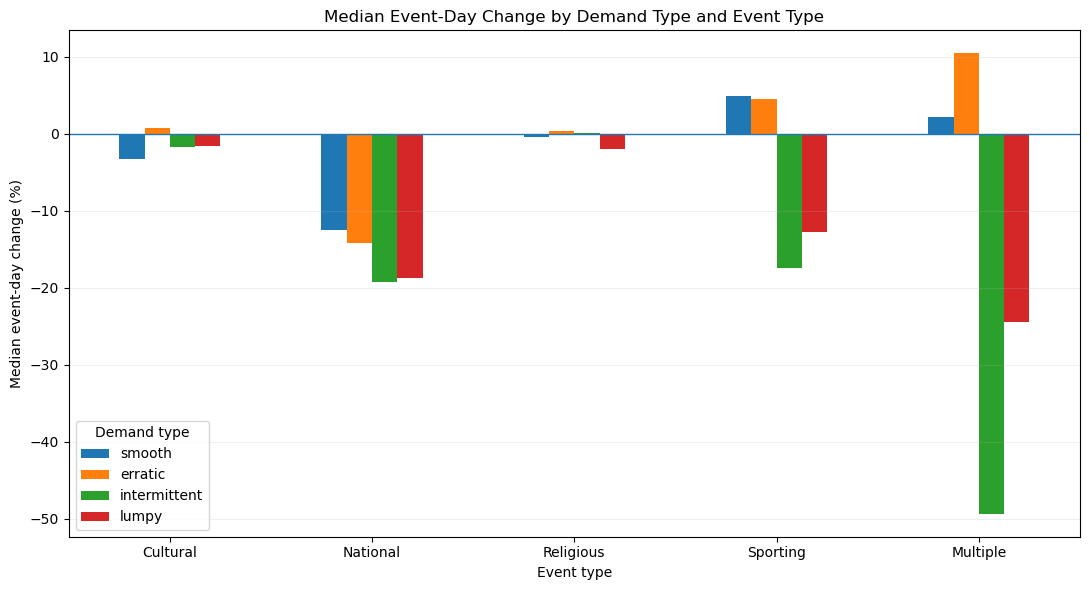

Saved: ..\outputs\figures\step13A\step13A_event_type_effect_by_demand_type.png


In [33]:
event_type_plot = (
    event_type_summary
    .pivot(
        index="event_type_label",
        columns="demand_type",
        values="median_event_uplift_pct"
    )
    .reindex(
        [
            "Cultural",
            "National",
            "Religious",
            "Sporting",
            "Multiple"
        ]
    )
    .reindex(
        columns=demand_type_order
    )
)

fig, ax = plt.subplots(
    figsize=(11, 6)
)

event_type_plot.plot(
    kind="bar",
    ax=ax
)

ax.axhline(
    0,
    linewidth=1
)

ax.set_xlabel("Event type")
ax.set_ylabel(
    "Median event-day change (%)"
)

ax.set_title(
    "Median Event-Day Change by Demand Type and Event Type"
)

ax.set_xticklabels(
    event_type_plot.index,
    rotation=0
)

ax.legend(
    title="Demand type"
)

ax.grid(
    axis="y",
    alpha=0.2
)

figure_file = (
    figures_path
    / "step13A_event_type_effect_by_demand_type.png"
)

fig.tight_layout()

fig.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_file)

**Figure 13A.1:** Median event-day change by demand type and event category.

In [34]:
event_type_summary.to_csv(
    tables_path
    / "step13A_event_type_effects.csv",
    index=False
)

binary_event_summary.to_csv(
    tables_path
    / "step13A_binary_event_effects.csv"
)

binary_vs_typed_event.to_csv(
    tables_path
    / "step13A_binary_vs_typed_event.csv",
    index=False
)

event_name_summary.to_csv(
    tables_path
    / "step13A_event_name_effects.csv",
    index=False
)

lowest_event_names_by_sparse_type.to_csv(
    tables_path
    / "step13A_lowest_event_names_sparse_types.csv",
    index=False
)

store_closure_summary.to_csv(
    tables_path
    / "step13A_store_closure_proxy.csv",
    index=False
)

store_type_effect.to_csv(
    tables_path
    / "step13A_store_event_type_effects.csv",
    index=False
)

zero_sales_event_days.to_csv(
    tables_path
    / "step13A_zero_sales_event_days.csv",
    index=False
)

zero_sales_event_summary.to_csv(
    tables_path
    / "step13A_zero_sales_event_summary.csv",
    index=False
)

print("All Step 13A tables saved.")

All Step 13A tables saved.


In [35]:
step13A_validation = pd.DataFrame([
    {
        "check": "Input rows",
        "actual": len(event_data),
        "expected": 1552800,
        "passed": (
            len(event_data)
            == 1552800
        )
    },
    {
        "check": "Input series",
        "actual": (
            event_data["id"].nunique()
        ),
        "expected": 800,
        "passed": (
            event_data["id"].nunique()
            == 800
        )
    },
    {
        "check": "Event rows",
        "actual": int(
            event_data[
                "event_flag"
            ].sum()
        ),
        "expected": 126400,
        "passed": (
            event_data[
                "event_flag"
            ].sum()
            == 126400
        )
    },
    {
        "check": "Demand types",
        "actual": (
            event_data[
                "demand_type"
            ].nunique()
        ),
        "expected": 4,
        "passed": (
            event_data[
                "demand_type"
            ].nunique()
            == 4
        )
    },
    {
        "check": "Series baselines",
        "actual": (
            non_event_baseline[
                "id"
            ].nunique()
        ),
        "expected": 800,
        "passed": (
            non_event_baseline[
                "id"
            ].nunique()
            == 800
        )
    },
    {
        "check": "Event-type codes",
        "actual": (
            event_data[
                "event_type_encoded"
            ].nunique()
        ),
        "expected": 6,
        "passed": (
            event_data[
                "event_type_encoded"
            ].nunique()
            == 6
        )
    },
    {
        "check": "Event-type summary rows",
        "actual": len(
            event_type_summary
        ),
        "expected": 20,
        "passed": (
            len(event_type_summary)
            == 20
        )
    },
    {
        "check": "Sparse event-name output rows",
        "actual": len(
            lowest_event_names_by_sparse_type
        ),
        "expected": 40,
        "passed": (
            len(
                lowest_event_names_by_sparse_type
            )
            == 40
        )
    },
    {
        "check": "Exact M5 store columns",
        "actual": len(
            store_columns
        ),
        "expected": 10,
        "passed": (
            len(store_columns)
            == 10
        )
    },
    {
        "check": "Normalised store-day rows",
        "actual": len(
            store_daily_sales
        ),
        "expected": 19410,
        "passed": (
            len(store_daily_sales)
            == 19410
        )
    },
    {
        "check": "Unique stores",
        "actual": (
            store_daily_sales[
                "store_id"
            ].nunique()
        ),
        "expected": 10,
        "passed": (
            store_daily_sales[
                "store_id"
            ].nunique()
            == 10
        )
    },
    {
        "check": "Missing store sales",
        "actual": (
            store_daily_sales[
                "total_sales"
            ].isna().sum()
        ),
        "expected": 0,
        "passed": (
            store_daily_sales[
                "total_sales"
            ].isna().sum()
            == 0
        )
    },
    {
        "check": "Duplicate store-date rows",
        "actual": (
            store_daily_sales
            .duplicated(
                ["store_id", "date"]
            )
            .sum()
        ),
        "expected": 0,
        "passed": (
            store_daily_sales
            .duplicated(
                ["store_id", "date"]
            )
            .sum()
            == 0
        )
    }
])

step13A_validation.to_csv(
    tables_path
    / "step13A_validation.csv",
    index=False
)

step13A_validation

,check,actual,expected,passed
0,Input rows,1552800,1552800,True
1,Input series,800,800,True
2,Event rows,126400,126400,True
3,Demand types,4,4,True
4,Series baselines,800,800,True
5,Event-type codes,6,6,True
6,Event-type summary rows,20,20,True
7,Sparse event-name output rows,40,40,True
8,Exact M5 store columns,10,10,True
9,Normalised store-day rows,19410,19410,True


In [36]:
print(
    "All Step 13A checks passed:",
    step13A_validation[
        "passed"
    ].all()
)

All Step 13A checks passed: True


## Step 13A Interpretation

### 13A.1 Validation and analysis coverage

The event diagnostic used all 1,552,800 observations from the balanced modelling subset. It included 800 item-store series, with 200 smooth, 200 erratic, 200 intermittent and 200 lumpy series.

A total of 126,400 observations occurred on dates containing at least 1 listed event. The diagnostic separated these observations into 5 event categories: Cultural, National, Religious, Sporting and Multiple.

Each of the 800 series had a valid non-event sales baseline, and 0 event uplift values were missing. The event-type calculation produced 4,000 series-category combinations, equal to 800 series multiplied by 5 event categories.

The full-store diagnostic used the correct 10 M5 stores and 19,410 store-date observations. It contained 0 missing store sales and 0 duplicate store-date rows.

### 13A.2 Binary event results hide event-category differences

The original binary event flag produced a negative median sales change for all 4 demand types:

* Smooth: −3.707%
* Erratic: −3.150%
* Intermittent: −7.066%
* Lumpy: −5.732%

These combined values hide clear differences between event categories. National events produced negative median changes for all 4 demand types, while religious events remained close to 0%.

For smooth demand, the median change was −12.541% on national event dates but 4.847% on sporting event dates. For erratic demand, the corresponding values were −14.223% and 4.441%.

The same contrast did not hold for sparse demand. Intermittent demand recorded a median sporting-event change of −17.440%, while lumpy demand recorded −12.785%.

The event-type feature therefore contains information that is lost when all events are represented using a single binary indicator.

### 13A.3 National events were the main repeated negative category

National events produced the most consistently negative category-level results:

* Smooth: −12.541%
* Erratic: −14.223%
* Intermittent: −19.222%
* Lumpy: −18.704%

Only 13.5% of smooth series, 14.5% of erratic series, 18.0% of intermittent series and 21.0% of lumpy series recorded a positive sales response on national event dates.

At full-store level, national events produced a median sales change of −14.541% and a mean change of −15.307%. This was lower than the median changes for Cultural events at −0.558%, Religious events at −0.531% and Sporting events at 2.642%.

National events therefore appear to be the main repeated contributor to the negative binary event result.

### 13A.4 Christmas and the closure proxy

The full-store diagnostic found 24 zero-sales store-days during the observed period. All 24 occurred on Christmas dates, affecting 8 stores across 5 Christmas dates.

National events contained 510 store-event observations, giving a full-store zero-sales closure-proxy rate of 4.706%. The other 4 event categories contained 0 full-store zero-sales observations.

Christmas also produced a median event-day change of −100.000% for both intermittent and lumpy demand. This means that at least half of the selected series in each group recorded no sales on the analysed Christmas dates relative to their non-event baseline.

The full-store zero-sales evidence supports the possibility that Christmas operating arrangements contributed to the national-event decline. However, the dataset does not contain confirmed store opening hours, so the 24 observations are treated as a closure proxy rather than proof that a store was closed.

The national-event effect cannot be explained entirely by the closure proxy because Christmas accounted for only 24 of the 510 national store-event observations. Thanksgiving and New Year also produced large negative median changes for intermittent and lumpy demand.

### 13A.5 Sparse demand reacted differently to sporting and multiple events

Sporting events had opposite relationships across dense and sparse demand.

Smooth demand recorded a median sporting-event increase of 4.847%, and erratic demand recorded 4.441%. Intermittent demand instead recorded −17.440%, while lumpy demand recorded −12.785%.

The individual sporting events support this difference. NBA Finals Start produced a median change of −38.103% for intermittent demand and −33.531% for lumpy demand. NBA Finals End produced −37.054% and −38.949%, respectively.

Multiple-event dates also produced contrasting results. Erratic demand recorded a median increase of 10.432%, while intermittent and lumpy demand recorded decreases of −49.373% and −24.469%.

The multiple-event result must be interpreted cautiously because it is based on only 4 event dates. Its extreme value may be sensitive to the small number of observations.

### 13A.6 Religious and cultural events were closer to neutral

Religious events produced category-level median changes of:

* Smooth: −0.422%
* Erratic: 0.338%
* Intermittent: 0.125%
* Lumpy: −2.057%

These results were much closer to 0% than the national-event changes of −12.541% to −19.222%.

Cultural events were also relatively close to neutral at category level, ranging from −3.340% for smooth demand to 0.795% for erratic demand.

Individual cultural and religious events still produced large positive or negative results. For example, Halloween produced a median change of −32.006% for intermittent demand, while the mean change was 3.794%. This difference shows that a small number of large increases can raise the mean even when the median series experienced lower sales.

Category-level results are therefore more stable for modelling interpretation than conclusions based on a single named event.

### 13A.7 Implications for feature engineering and ablation

The binary `event_flag` treats national, religious, cultural and sporting dates as equivalent, although their median effects differ by more than 20 percentage points within some demand types.

For intermittent demand, the median change ranged from 0.125% for religious events to −49.373% for multiple-event dates. For smooth demand, it ranged from −12.541% for national events to 4.847% for sporting events.

The event-type feature should therefore be evaluated separately from the binary event flag when interpreting the Step 17 ablation and Step 18 SHAP results.

A weak overall contribution from the event feature group would not mean that every event category is uninformative. Positive and negative category effects may offset one another when represented inside one combined feature group.

### 13A.8 Conclusion

The negative event-day result is concentrated mainly in national events rather than being evenly spread across every category.

National events produced median changes between −12.541% and −19.222% across all 4 demand types. Religious events remained between −2.057% and 0.338%.

Sporting events separated dense and sparse demand. Smooth and erratic demand recorded positive median changes of 4.847% and 4.441%, while intermittent and lumpy demand recorded negative changes of −17.440% and −12.785%.

The event-type diagnostic therefore supports the conclusion that event category matters more than the simple presence of an event. These results remain descriptive and do not establish that an event caused the observed sales change.


### Surprise Log

The main surprise in Step 13A was that sporting events produced opposite results across demand types. Smooth and erratic demand recorded median increases of 4.847% and 4.441%, while intermittent and lumpy demand recorded decreases of −17.440% and −12.785%.

A second surprise was that all 24 full-store zero-sales event observations occurred on Christmas dates. These observations affected 8 of the 10 stores across 5 Christmas dates.

The most extreme category result was the −49.373% median change for intermittent demand on multiple-event dates. However, this category contained only 4 dates, so the result should not be treated as equally stable as the national-event result based on 51 dates.
